## 25.09.21: Line and Conic Detection

In [1]:
import sys, os, json
sys.path.append(os.path.abspath('..'))

from tqdm import tqdm
from itertools import pairwise

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import cv2
from ultralytics import YOLO

from scripts.datasets.calibration import CalibrationDataset
from scripts.datasets.field_masking import MaskingCalibrationDataset
from SoccerNet.Downloader import SoccerNetDownloader

print(f'Torch CUDA availability: {torch.cuda.is_available()}')
print(f'Torch MPS availability: {torch.mps.is_available()}')

Torch CUDA availability: False
Torch MPS availability: True


/Users/sam/miniconda3/envs/ISC-Football/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
masking_calibration_train_dataset = MaskingCalibrationDataset.from_folder('../data/calibration/train', width=320, height=180, n_limit=128,
                                                                          mode='train', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
masking_calibration_test_dataset = MaskingCalibrationDataset.from_folder('../data/calibration/test', width=320, height=180, n_limit=128,
                                                                          mode='test', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
masking_calibration_valid_dataset = MaskingCalibrationDataset.from_folder('../data/calibration/valid', width=320, height=180, n_limit=128,
                                                                          mode='valid', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
print(f'Number of training samples: {len(masking_calibration_train_dataset)}')
print(f'Number of test samples: {len(masking_calibration_test_dataset)}')
print(f'Number of valid samples: {len(masking_calibration_valid_dataset)}')

Number of training samples: 128
Number of test samples: 128
Number of valid samples: 128


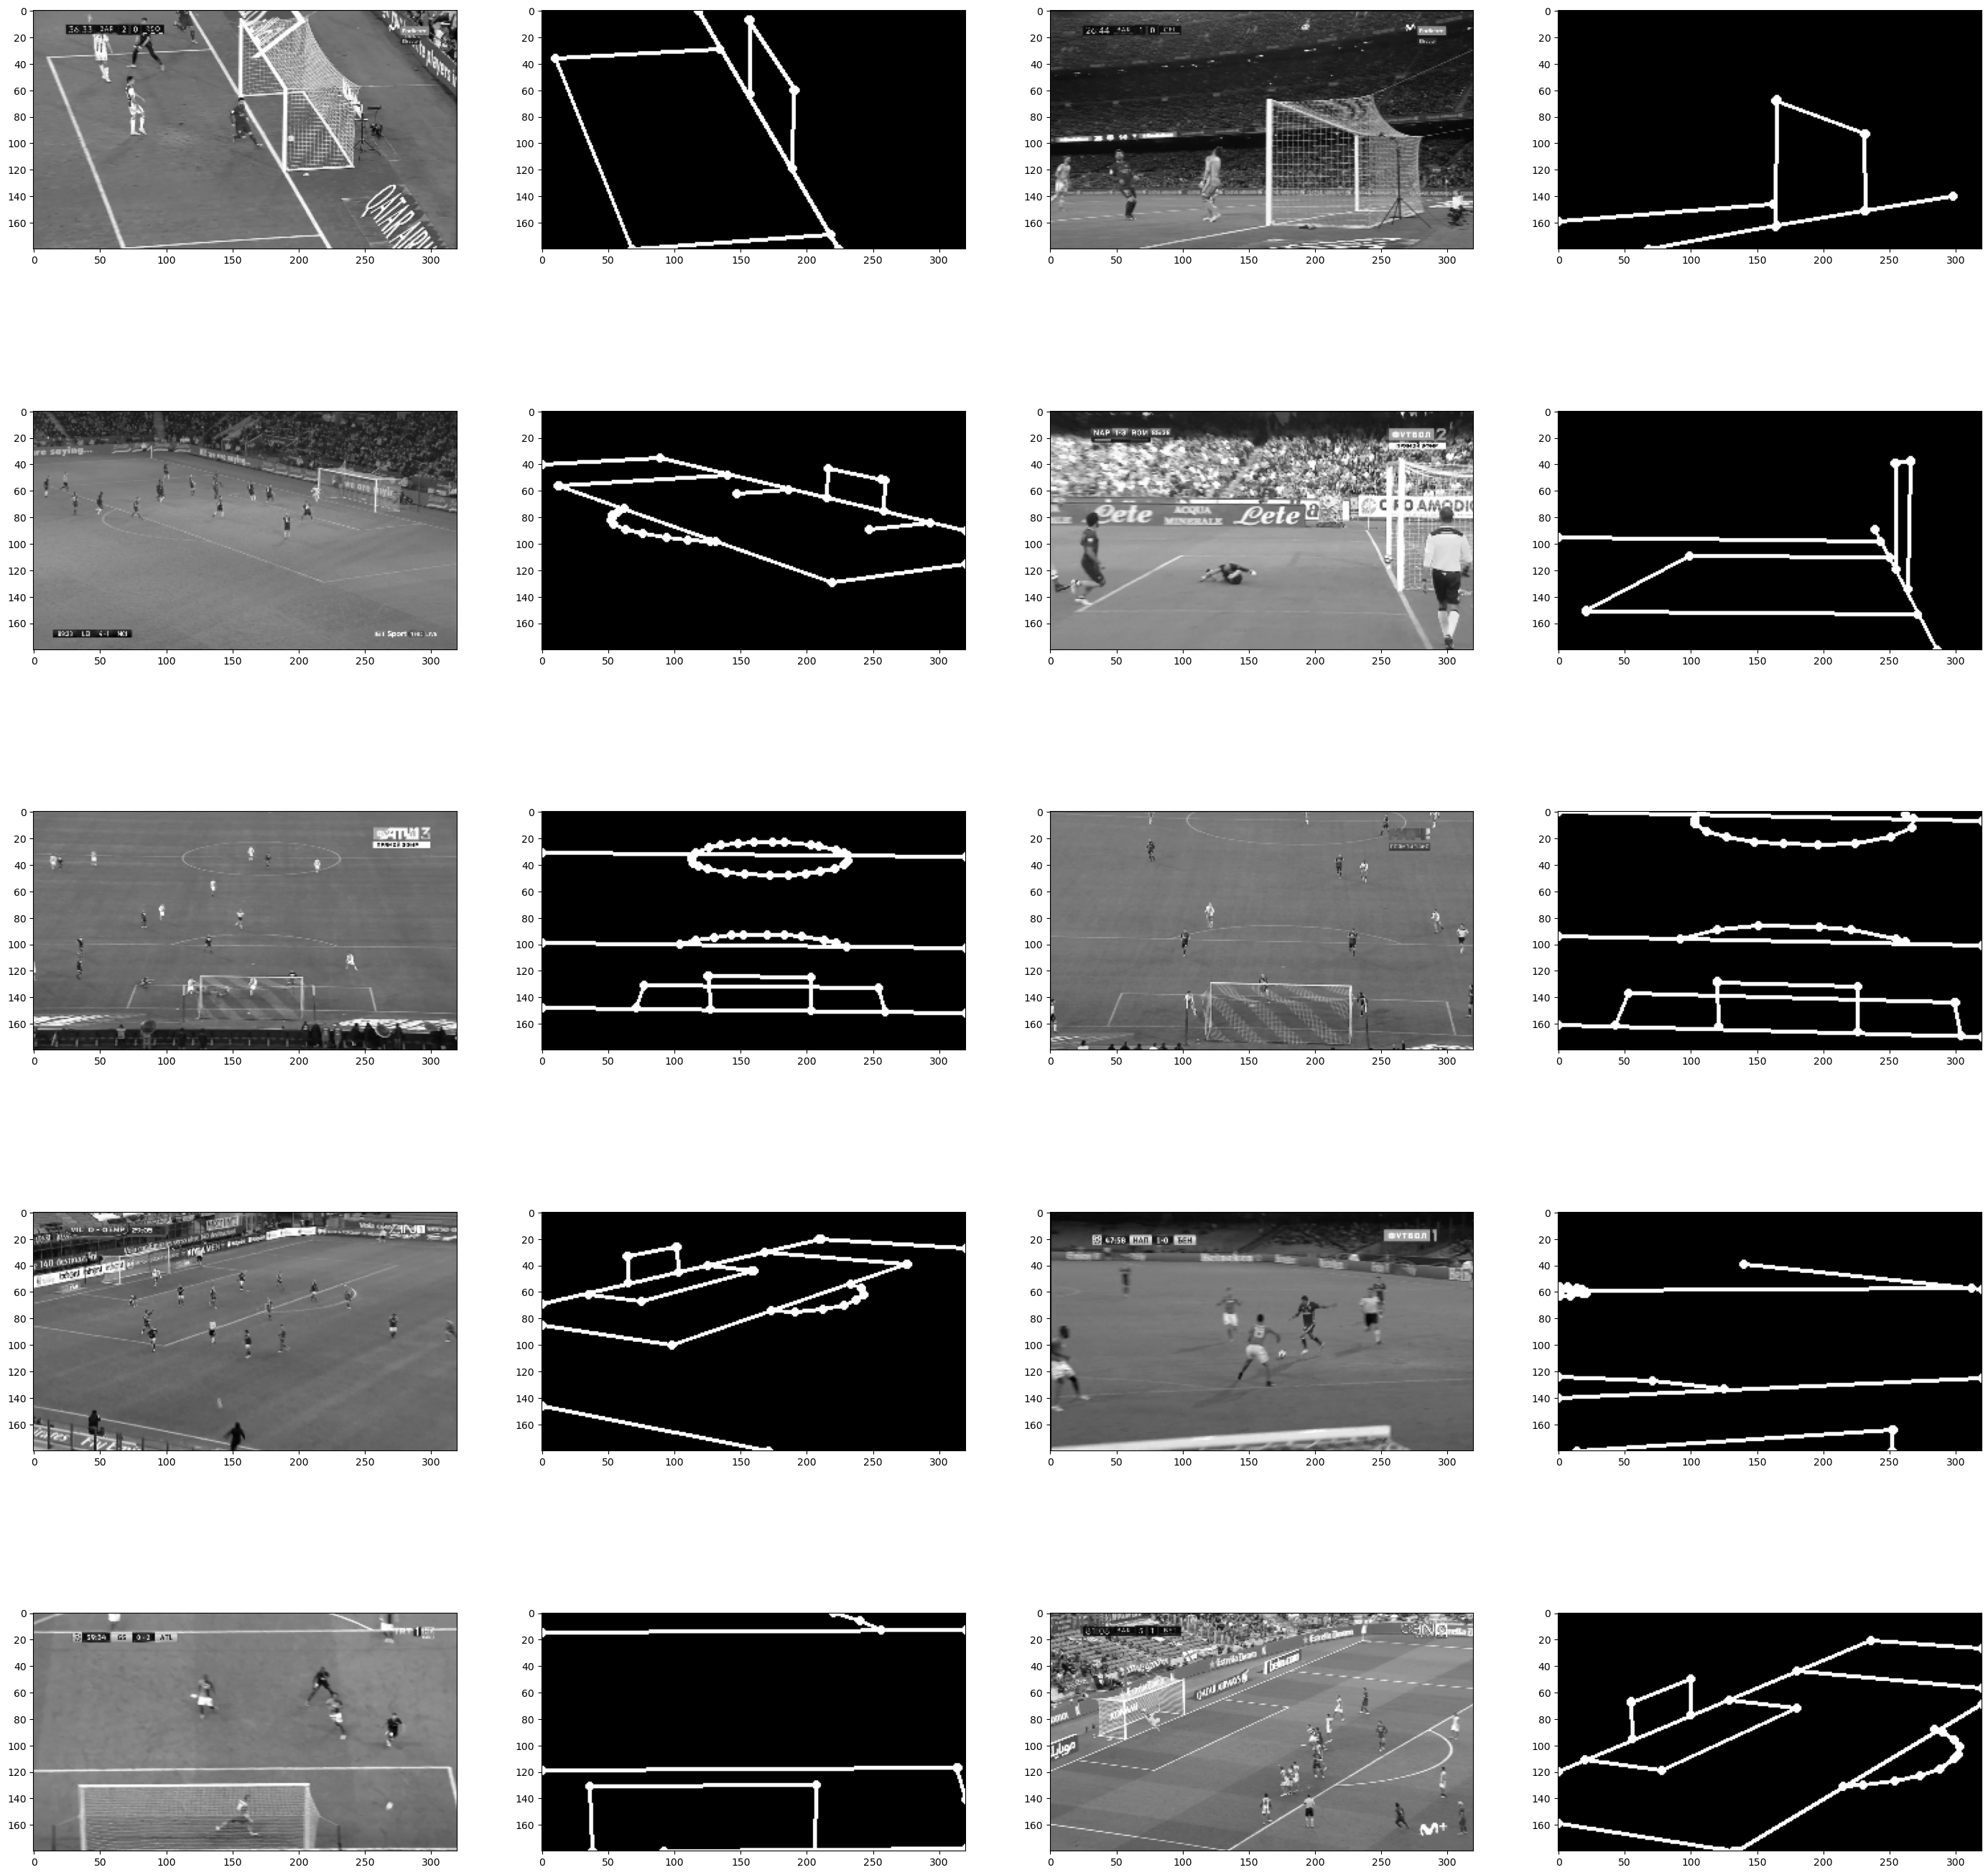

In [3]:
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(35, 35))

for idx in range(0, len(axes.flat), 2):
    img, mask = masking_calibration_train_dataset[idx]
    # img = (img * 255).astype('uint8')
    # img = cv2.equalizeHist(img)
    # img = (img / 255).astype('float')
    axes.flat[idx].imshow(img, cmap='gray')
    axes.flat[idx + 1].imshow(mask, cmap='gray')

plt.show()

## UNet

https://arxiv.org/abs/2504.14131

In [4]:
DEVICE = torch.device('cpu')
torch.mps.empty_cache()

torch.hub.load('sm00thix/unet', 'unet', pretrained=False, in_channels=1, out_channels=1, pad=True, bilinear=True, normalization='bn')
unet_model = torch.load('../weights/experimental/251006-unet-model.pt').to(DEVICE)
unet_model.eval()

print(f'UNet model device: {next(unet_model.parameters()).device}')

Using cache found in /Users/sam/.cache/torch/hub/sm00thix_unet_main
/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_41285/262586736.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this ex

UNet model device: cpu


In [5]:
torch.mps.empty_cache()

batch_size = 4
valid_dataloader = DataLoader(masking_calibration_train_dataset, batch_size=batch_size, shuffle=False)
img, mask = next(iter(valid_dataloader))
img = img.float().unsqueeze(1).to(DEVICE)
mask = mask.float().unsqueeze(1).to(DEVICE)

unet_model.eval()
out_mask = unet_model(img)
print(f'img.shape = {img.shape}, out_mask.shape = {out_mask.shape}, mask.shape = {mask.shape}')

img = img.to('cpu')
mask = img.to('cpu')

img.shape = torch.Size([4, 1, 180, 320]), out_mask.shape = torch.Size([4, 1, 180, 320]), mask.shape = torch.Size([4, 1, 180, 320])


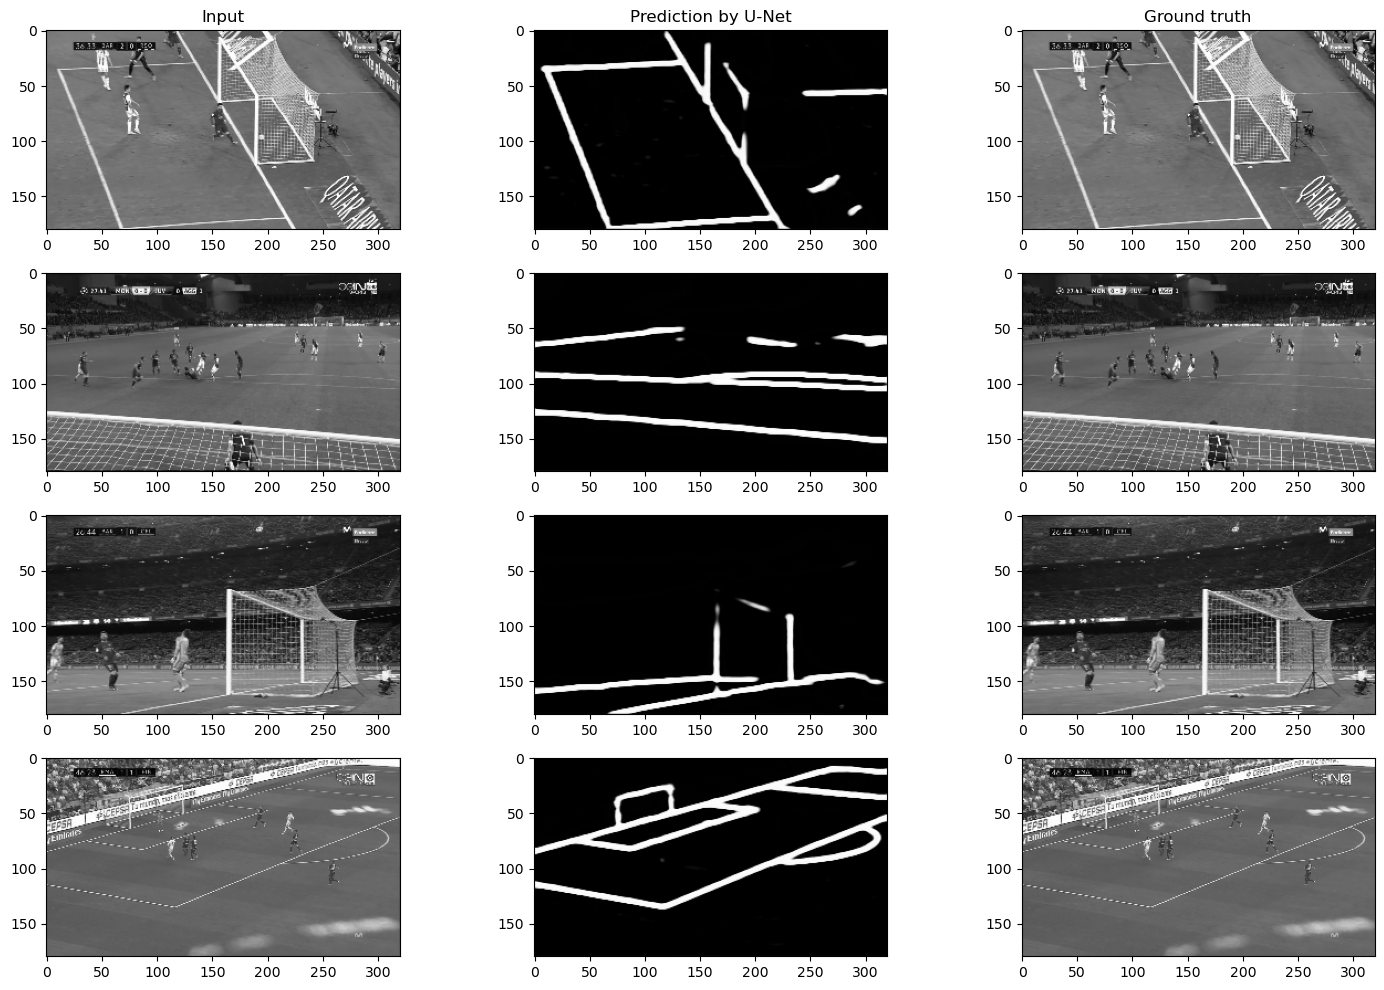

In [6]:
fig, axes = plt.subplots(nrows=batch_size, ncols=3, figsize=(15, 10))
def img_convert(img):
    return img.permute((1, 2, 0)).cpu().detach().numpy()

for idx in range(batch_size):
    axes[idx, 0].imshow(img_convert(img[idx]), cmap='gray')
    axes[idx, 1].imshow(img_convert(out_mask[idx]), cmap='gray')
    axes[idx, 2].imshow(img_convert(mask[idx]), cmap='gray')

axes[0, 0].set_title('Input')
axes[0, 1].set_title('Prediction by U-Net')
axes[0, 2].set_title('Ground truth')

fig.tight_layout()
plt.show()

## Homography Estimation Net

Paper: https://arxiv.org/pdf/1606.03798

In [101]:
def homography_matrix(old_pts, new_pts: torch.Tensor):
    # print(old_pts, new_pts)

    n_batch = old_pts.shape[0]
    assert old_pts.shape[1:] == (4, 3)
    assert new_pts.shape[1:] == (4, 3)

    new_xs, new_ys, new_zs = new_pts[:, :, 0], new_pts[:, :, 1], new_pts[:, :, 2]
    pz = new_zs.unsqueeze(-1) * old_pts
    px = new_xs.unsqueeze(-1) * old_pts
    py = new_ys.unsqueeze(-1) * old_pts

    zeros = torch.zeros_like(px)

    # Ah = 0
    A = torch.cat((
        torch.cat((pz, zeros, -px), dim=2),
        torch.cat((zeros, pz, -py), dim=2)
    ), dim=1)

    U, S, VT = torch.linalg.svd(A)
    h = VT[:, -1, :].unsqueeze(-1)
    H = h.reshape(n_batch, 3, 3)
    # H /= H[2, 2]

    print(A.shape, h.shape)
    # print(f"A @ h = {A @ h}")

    res = old_pts @ H.permute((0, 2, 1))
    res /= res[:, :, 2].unsqueeze(-1)
    # print(f"X @ H.T ~ {res}")

    return H

A = torch.Tensor([[0, 0, 1], [0, 1, 1], [1, 1, 1], [1, 0, 1]])
B = torch.Tensor([[1, 1, 1], [2, 1, 1], [3, 2, 1], [2, 2, 1]])

homography_matrix(
    old_pts=torch.stack((A, B, A, B), dim=0),
    new_pts=torch.stack((B, A, A, B), dim=0)
)

torch.Size([4, 8, 9]) torch.Size([4, 9, 1])


tensor([[[ 4.0825e-01,  4.0825e-01,  4.0825e-01],
         [ 4.0825e-01, -2.0018e-07,  4.0825e-01],
         [ 3.2327e-07, -1.4660e-07,  4.0825e-01]],

        [[ 1.4788e-07,  4.4721e-01, -4.4721e-01],
         [ 4.4721e-01, -4.4721e-01,  4.1002e-08],
         [ 2.4107e-07, -5.0042e-07,  4.4721e-01]],

        [[ 5.7735e-01,  3.4152e-08,  0.0000e+00],
         [-8.5386e-09,  5.7735e-01, -6.2064e-09],
         [ 4.4538e-08,  1.7691e-07,  5.7735e-01]],

        [[ 5.7735e-01, -1.7814e-07, -2.8245e-07],
         [ 2.9981e-07,  5.7735e-01, -2.5620e-07],
         [ 2.3775e-07, -1.7949e-07,  5.7735e-01]]])

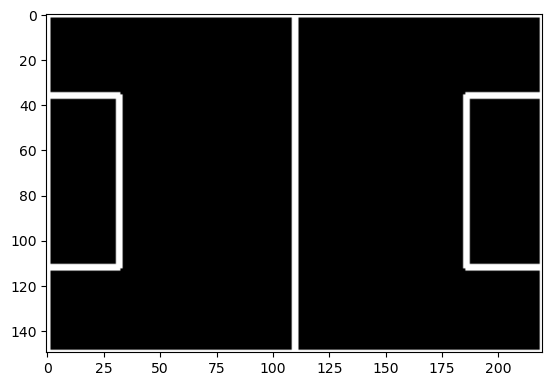

In [33]:
class FootballPitch:
    HEIGHT = 75
    WIDTH = 110

    def __init__(self):
        with open('football_pitch.json') as f:
            data_dict = json.load(f)

        self.n_points = len(data_dict)
        self.keypoints = torch.Tensor(list(data_dict.values()))
        ones = torch.ones(self.n_points).unsqueeze(-1)
        self.keypoints = torch.cat((self.keypoints, ones), dim=1)

        self.names = list(data_dict.keys())
        self.key_mapping = dict({name: idx for idx, name in enumerate(self.names)})

        self.polygons = [
            ['field_top_left', 'midfield_top', 'midfield_bottom', 'field_bottom_left'],
            ['midfield_top', 'field_top_right', 'field_bottom_right', 'midfield_bottom'],
            ['left_penalty_top_left', 'left_penalty_top_right', 'left_penalty_bottom_right', 'left_penalty_bottom_left'],
            ['right_penalty_top_left', 'right_penalty_top_right', 'right_penalty_bottom_right', 'right_penalty_bottom_left'],
        ]


    def apply_homography(self, H: torch.Tensor) -> "FootballPitch":
        # Need (H * P^T)^T = P * H^T
        print(self.keypoints, H.T)
        print(self.keypoints.shape, H.T.shape)
        self.keypoints = torch.matmul(self.keypoints, H.T)
        return self

    def _xy_point(self, descriptor: str) -> tuple:
        y, x, z = self.keypoints[self.key_mapping[descriptor]]
        return [int(x / z), int(y / z)]

    def image(self, scale: int = 1) -> np.ndarray:
        img = np.zeros((FootballPitch.HEIGHT * scale, FootballPitch.WIDTH * scale), dtype='uint8')
        polys = [[self._xy_point(label) for label in polygon_labels] for polygon_labels in self.polygons]
        polys = np.array(polys, dtype='int32') * scale
        img = cv2.polylines(img, polys, True, 255, scale)

        return img

pitch = FootballPitch()
plt.imshow(pitch.image(scale=2), cmap='gray')


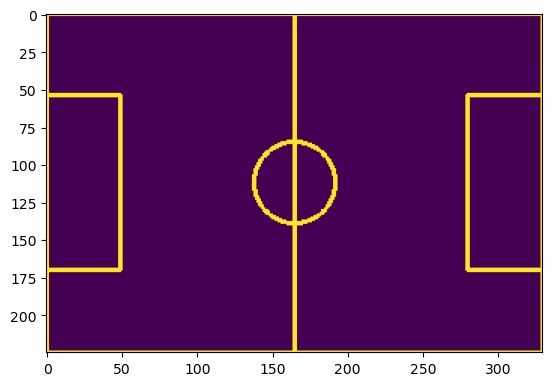

In [8]:
def football_pitch(width=110, height=75, scale=None):
    if scale is None:
        scale = 1

    bboxes = {
        'Field': (0, 0, width, height),
        'Midfield': (width / 2, 0, width / 2, height),
        'Penalty box left': (0, (height - 38.52) / 2, 16.50, (height + 38.52) / 2),
        'Penalty box right': (width - 16.50, (height - 38.52) / 2, width, (height + 38.52) / 2),
    }

    arcs = {
        'Midcircle': (width / 2, height / 2, 9.15)
    }

    img = np.zeros((height * scale, width * scale), dtype='uint8')
    for (x1, y1, x2, y2) in bboxes.values():
        x1, y1, x2, y2 = map(lambda p: int(scale * p), (x1, y1, x2, y2))
        img = cv2.rectangle(img, (x1, y1), (x2, y2), 255, 2)

    for (x0, y0, r) in arcs.values():
        x0, y0, r = map(lambda p: int(scale * p), (x0, y0, r))
        img = cv2.ellipse(img, (x0, y0), (r, r), 0, 0, 360, 255, 2)

    return img

pitch = football_pitch(scale=3)
plt.imshow(pitch)
plt.show()

In [15]:
class HomographyNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Conv 1: 180x320x1 -> 90x160x32
        self.conv1 = nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Conv 2: 90x160x32 -> 45x80x64
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Conv 3: 45x80x64 -> 22x40x128
        self.conv3 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Conv 4: 22x40x128 -> 11x20x256
        self.conv4 = nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        
        # Conv 5: 11x20x256 -> 11x20x256 (Preserve size, increase feature complexity)
        self.conv5 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)
        self.bn5 = nn.BatchNorm2d(256)

        # Flattened size: 11 * 20 * 256 = 56320
        self.fc_input_size = 11 * 20 * 256
        
        # Dense 1: 56320 -> 220
        self.fc1 = nn.Linear(self.fc_input_size, 220)
        
        # Dense 2: 220 -> 8 (Final Output)
        self.fc2 = nn.Linear(220, 8)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = F.relu(self.bn5(self.conv5(x)))

        x = x.view(-1, self.fc_input_size)          # Flatten layer: 11 * 20 * 256 = 56320 elements
        x = F.relu(self.fc1(x))                     # Dense layers
        x = self.fc2(x)                             # Final output layer (8 elements for the homography parameters)
        x = x.view(-1, 4, 3)                        # Reshape to matrix 4 x 3
        
        return x

In [16]:
print(hom_mat_inv)


tensor([[[-0.0200,  0.0562],
         [ 0.2727,  0.0872],
         [-0.0698, -0.2483],
         [-0.2721,  0.1210]],

        [[ 0.0211,  0.2445],
         [-0.0372, -0.0840],
         [-0.0061, -0.0947],
         [-0.4074,  0.0398]],

        [[ 0.1271,  0.1750],
         [ 0.3850, -0.1017],
         [-0.0416, -0.0966],
         [-0.0958, -0.1422]],

        [[-0.0247,  0.4215],
         [-0.1383,  0.0733],
         [-0.0846, -0.2909],
         [-0.4138, -0.0282]]], grad_fn=<ViewBackward0>)


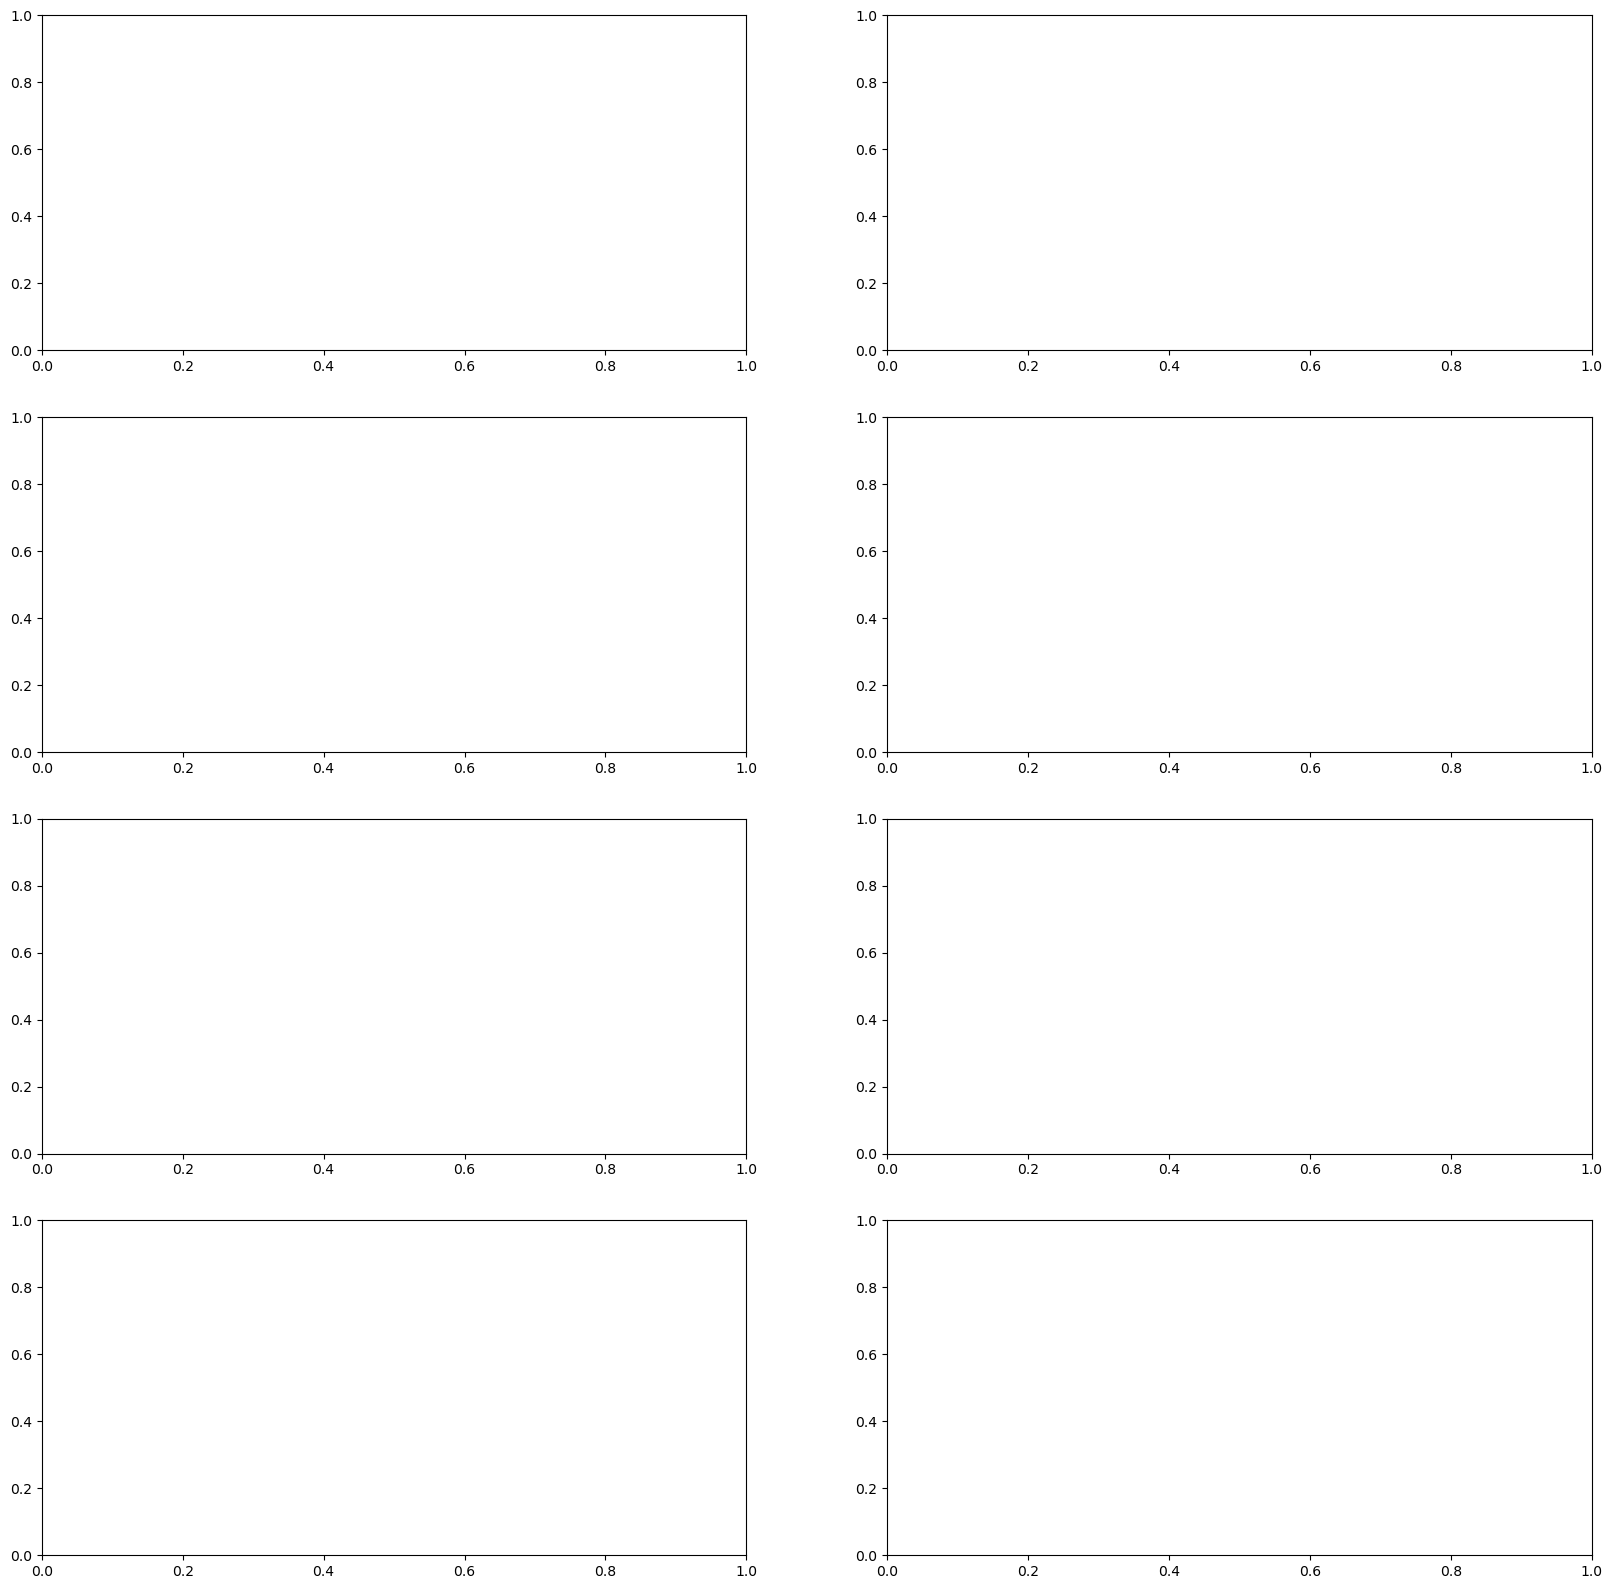

In [11]:
IDX = 3
fig, axes = plt.subplots(nrows=batch_size, ncols=2, figsize=(20, 20))
hom_net = HomographyNet()

img_one = unet_model(img)
hom_mat_inv = hom_net(img_one)
# theta = np.pi / 7
# hom_mat_inv = torch.Tensor(
#     [
#         [[1, 0, 0], [0, np.cos(theta), -np.sin(theta)], [0, np.sin(theta), np.cos(theta)]],
#         [[1, 0, 0], [0, 1, 0], [0, 0, 1]],
#         [[1, 0, 0], [0, 1, 0], [0, 0, 1]],
#         [[1, 0, 0], [0, 1, 0], [0, 0, 1]],
#     ]
# )

# print(hom_mat_inv, hom_mat_inv.shape)

# for i in range(batch_size):
#     axes[i, 0].imshow(img_one[i][0].detach().numpy(), cmap='gray')
#     # axes[i, 1].imshow(img_one[i][0].detach().numpy(), cmap='gray')
#     pitch = FootballPitch().apply_homography(hom_mat_inv[i])
#     axes[i, 1].imshow(pitch.image() , cmap='gray')
#     print(pitch.keypoints)

# plt.show()

## Field Localisation
Paper: https://openaccess.thecvf.com/content_cvpr_2017/papers/Homayounfar_Sports_Field_Localization_CVPR_2017_paper.pdf

Line: https://visionbook.mit.edu/3d_scene_understanding_single_view.html

<center>
    <img width="40%" src="media/field-parameterisation.png" />
    <img width="40%" src="media/horizon-line.png" />
</center>

### A projective model of the football pitch

In [ ]:
def normalise_homogeneous(x):
    return x / x[2]

def plot_ray(ax, ray, T=1000):
    rray_1 = np.random.rand(3)
    rray_2 = np.random.rand(3)
    pt1 = normalise_homogeneous(np.cross(ray, rray_1))
    pt2 = normalise_homogeneous(np.cross(ray, rray_2))
    dp = pt2 - pt1
    pt1 -= T * dp
    pt2 += T * dp
    pt1 = normalise_homogeneous(pt1)
    pt2 = normalise_homogeneous(pt2)
    ax.plot([pt1[0], pt2[0]], [pt1[1], pt2[1]])

In [ ]:
def football_field(ax, ray_v1, ray_v2, ray_h1, ray_h2):
    src_v = normalise_homogeneous(np.cross(ray_v1, ray_v2))
    src_h = normalise_homogeneous(np.cross(ray_h1, ray_h2))
    plot_ray(ax, ray_v1)
    plot_ray(ax, ray_v2)
    print(ray_v1, ray_v2)

SRC_V, SRC_H = (450, -550, 1), (-450, 350, 1)
RAY_V0 = [(2, 3, 1)]

print(RAY_GRADs_V, RAY_GRADs_H)
print(RAYs_V, RAYs_H)

fig, ax = plt.subplots(1, 1)
football_field(ax, *RAYs_V, *RAYs_H)
plt.show()

NameError: name 'RAY_GRADs_V' is not defined